# The Energy of Soil Water — Interactive Notebook

**MOOC "The Hydrology of Soil" — Chapter 2**

---

Chapter 2 makes one central claim: the **mechanically stable configuration of
water in a soil is the one in which the smallest pores are filled and the
largest are empty**. From that single idea — together with the **Young–Laplace
relation** — follows a *unique* relationship between water content and suction:
the **soil water retention curve (SWRC)**.

This notebook lets students *build* that curve themselves:

1. start from a **pore-size distribution** — a bag of pores of different radii;
2. apply the rule "**fill smallest first**" and the **Young–Laplace relation**
   to obtain the retention curve θ(ψ) — the curve is *constructed*, not fitted;
3. compare this constructed curve with the standard **van Genuchten** formula;
4. explore the **energy "Rosetta stone"** — the same physical quantity written
   as chemical potential μ, as hydric potential Ψ (a pressure), and as
   hydraulic head h (a length).

Run the cells in order (Shift+Enter). Plain NumPy — no special packages needed.


## 0 — Setup

Run the package import cell below. If you have just updated the GitHub package, reinstall it first, then restart the runtime before continuing.

In [1]:
try:
    from soil_course import *
    print("soil_course already available")
except ModuleNotFoundError:
    !pip install git+https://github.com/unitrento/icts-moodle-packages-soil_course.git
    from soil_course import *

print("Setup complete")

  Cloning https://github.com/panzerotto/soil_course.git to /tmp/pip-req-build-szk2etx3
  Running command git clone --filter=blob:none --quiet https://github.com/panzerotto/soil_course.git /tmp/pip-req-build-szk2etx3
  Resolved https://github.com/panzerotto/soil_course.git to commit 15a4ab537065dcb406b18b305648221723661e4d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for soil-course: filename=soil_course-0.1.0-py3-none-any.whl size=10406 sha256=903e9cd0de755b944fa85d5bbbfcfa792009f9ddae955d5e1330f41c708cdd37
  Stored in directory: /tmp/pip-ephem-wheel-cache-eyecxflj/wheels/d1/cc/3a/6e11e3051820dbb8642dabb07e7fbe97d50387e4b7f07545bd
Successfully built soil-course
Setup complete


## 1 — The Young–Laplace relation: one pore, one suction

A spherical air–water meniscus of radius $r$ in a pore sustains a pressure
jump

$$|\psi_p| \;=\; \frac{2\sigma}{\rho_w g\, r},$$

where $\psi_p$ is the **pressure head** (here expressed as a length of water
column). A *small* pore holds water at *large* suction; a *large* pore empties
at *small* suction. This is the hinge of the whole chapter.

A pore of radius $r$ **stays full** as long as the applied suction $|\psi|$ is
below its own $|\psi_p(r)|$, and **drains** once $|\psi|$ exceeds it.


In [2]:
show_young_laplace_examples()

pore radius  1000.0 um  ->  empties at suction      0.015 m  (        1.5 cm )
pore radius   100.0 um  ->  empties at suction      0.148 m  (       14.8 cm )
pore radius    10.0 um  ->  empties at suction      1.484 m  (      148.4 cm )
pore radius     1.0 um  ->  empties at suction     14.842 m  (     1484.2 cm )
pore radius     0.1 um  ->  empties at suction    148.420 m  (    14842.0 cm )


Notice the range: a 1 mm pore empties almost immediately (a few cm of
suction), while a 0.1 µm pore holds water to ~150 m of suction — the
conventional *wilting point*. The pore-size axis and the suction axis are the
**same axis**, read through Young–Laplace.


## 2 — A pore-size distribution

Real soil has pores of many sizes. We describe them by a **lognormal
distribution** of pore radius — a simple, standard, two-parameter choice:

* `r_median` — the median pore radius (µm);
* `sigma_p` — the spread (standard deviation of ln r): small = uniform pores,
  large = a wide mixture.

The function below returns a discrete set of pore *classes*: their radii and
the **fraction of pore volume** each class contributes.


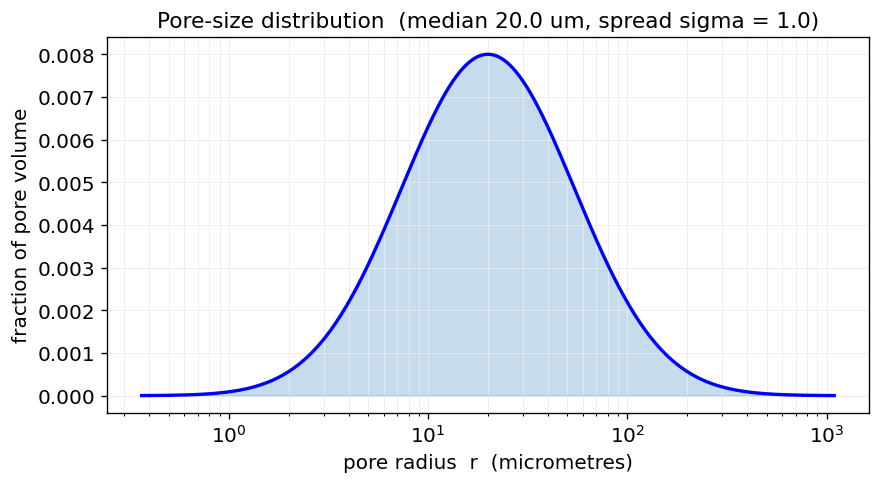

In [3]:
plot_pore_distribution(r_median=20.0, sigma_p=1.0)

## 3 — Building the retention curve: "fill smallest first"

Now the central construction. At a given suction $|\psi|$:

* every pore with $|\psi_p(r)| > |\psi|$ — that is, every pore **smaller** than
  the critical radius $r^\*(\psi)$ — is **still full**;
* every larger pore is **empty**.

So the water content at suction $|\psi|$ is simply the **cumulative pore
volume up to** $r^\*(\psi)$:

$$\theta(\psi) \;=\; \theta_r + (\theta_s-\theta_r)\!\!
   \sum_{r \,<\, r^\*(\psi)}\! \text{vol\_frac}(r),
   \qquad r^\*(\psi) = \frac{2\sigma}{\rho_w g\,|\psi|}.$$

This is the retention curve — and it was **constructed from the pore-size
distribution**, not fitted. The "smallest filled, largest empty" rule *is* the
SWRC.


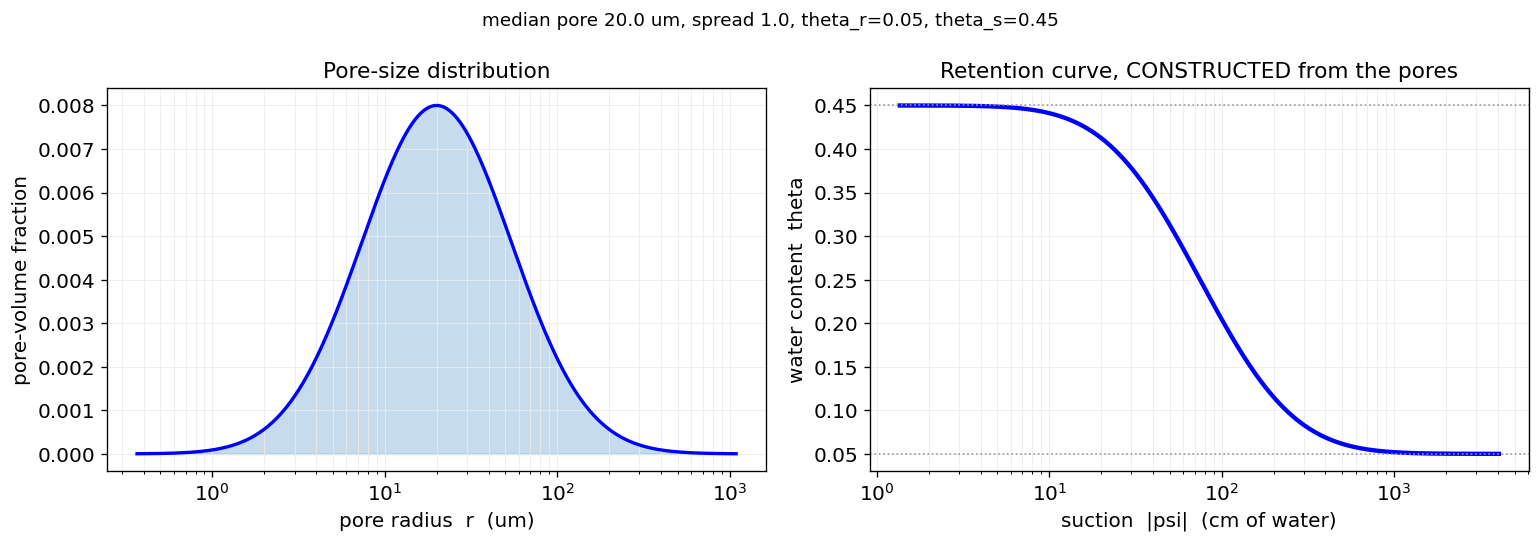

In [4]:
plot_constructed_swrc()

Read the two panels together: the **right-hand curve is the left-hand
distribution, integrated**. A narrow pore distribution gives a steep,
step-like retention curve; a broad distribution gives a gentle one. Change the
spread and watch both panels move.


## 4 — Interactive: pores → retention curve

Move the sliders and watch the retention curve being rebuilt:

* **median pore radius** — slides the curve along the suction axis;
* **spread** — steep (uniform pores) vs gentle (broad mixture);
* **θr, θs** — the residual and saturated water contents.

> Without `ipywidgets`, call `plot_constructed_swrc(...)` directly.


In [5]:
interactive_constructed_swrc()

interactive(children=(FloatLogSlider(value=20.0, continuous_update=False, description='median r (um)', max=3.0…

## 5 — The constructed curve vs the van Genuchten formula

The **van Genuchten** retention curve used in Chapters 3–5 is an empirical
formula:

$$S_e(\psi) = \big[\,1 + (\alpha|\psi|)^{n}\,\big]^{-m},\qquad m = 1 - 1/n.$$

It is *not* derived from a pore-size distribution — but it can be made to look
almost identical to one. The cell below overlays the **constructed** curve
(from the pores) and a **van Genuchten** curve, so students can see that the
empirical formula is a smooth stand-in for the pore-integration picture.


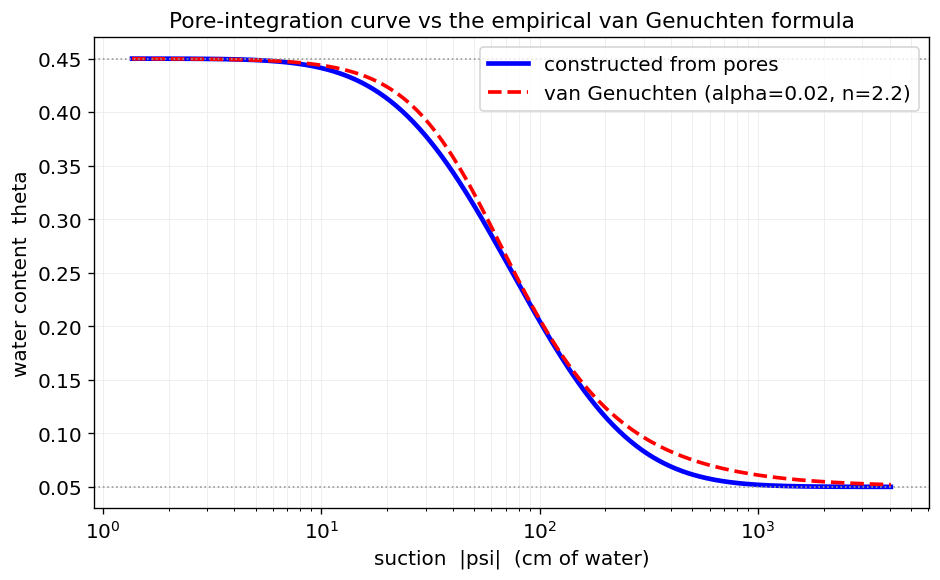

In [6]:
compare_curves(r_median=20.0, sigma_p=1.0, alpha=0.02, n=2.2)

In [7]:
interactive_compare_curves()

interactive(children=(FloatLogSlider(value=20.0, continuous_update=False, description='median r (um)', max=3.0…

## 6 — The energy "Rosetta stone"

Chapter 2 stresses that the energy of soil water is **one** physical quantity
written in **three** equivalent ways — different normalisations of the same
thing:

| name | symbol | normalised per | units |
|------|--------|----------------|-------|
| chemical potential | μ − μ\* | unit **mass** | J/kg |
| hydric potential   | Ψ | unit **volume** | Pa (= J/m³) |
| hydraulic / pressure head | h, ψ | unit **weight** | m of water |

They are linked by the density of water:

$$\Psi = \rho_w\,(\mu-\mu^\*),\qquad h = \frac{\Psi}{\rho_w g} = \frac{\mu-\mu^\*}{g}.$$

The converter below lets students enter a value in any one of the three and
read it back in the other two.


In [8]:
show_energy_rosetta(value=-150.0, unit="head_m")

The same soil-water energy state expressed three ways:

  hydraulic head      h   = -150.0000 m  ( -15000.0 cm )
  hydric potential    Psi = -1.472e+06 Pa  ( -1471.50 kPa )
  chemical potential  mu  = -1471.5000 J/kg


In [9]:
interactive_energy_rosetta()

interactive(children=(FloatText(value=-150.0, description='value'), Dropdown(description='given as', options=(…